<a href="https://colab.research.google.com/github/dadhikari9804-sys/AI-application-project/blob/main/Final_Project_Animal_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Runtime → Change runtime type → GPU**

In [ ]:
!nvidia-smi

In [ ]:
import glob
import os
import requests
import shutil

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from PIL import Image
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
##############################
# 1. Prepare data
##############################
file_id = "1N0b0beeMmvTDOqjnDzoBpoBNq3mVrHQb"
# gdown.download(, "animals.zip", quiet=False)
URL: str = f"https://drive.google.com/uc?id={file_id}"

zip_file: str = tf.keras.utils.get_file(
    origin=URL,
    fname="flower_photos.tgz",
    extract=True
)

2371/2371 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipython-input-1612068910.py:8: UserWarning: Could not extract archive.
  zip_file: str = tf.keras.utils.get_file(


In [ ]:
!pip install gdown
import gdown


In [ ]:
# Download the archive (expect around 40 seconds)
file_id = "1N0b0beeMmvTDOqjnDzoBpoBNq3mVrHQb"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "animals.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1N0b0beeMmvTDOqjnDzoBpoBNq3mVrHQb
From (redirected): https://drive.google.com/uc?id=1N0b0beeMmvTDOqjnDzoBpoBNq3mVrHQb&confirm=t&uuid=693baf66-023a-4d71-9d22-d0e6681c8073
To: /content/animals.zip
100%|██████████| 2.71G/2.71G [00:45<00:00, 60.0MB/s]


'animals.zip'

In [ ]:
!unzip animals.zip

Archive:  animals.zip
   creating: animals/
   creating: animals/dolphin/
  inflating: animals/dolphin/10494889073_8fc02ffa08_o.jpg  
  inflating: animals/dolphin/10746505353_994624d874_o.jpg  
  inflating: animals/dolphin/108972739_3d186c639f_o.jpg  
  inflating: animals/dolphin/10972014613_aa893b2eb7_o.jpg  
  inflating: animals/dolphin/11054709125_5bf2cf1765_o.jpg  
  inflating: animals/dolphin/11054723365_0b839634a1_o.jpg  
 extracting: animals/dolphin/11054791486_20bc4f9acf_o.jpg  
  inflating: animals/dolphin/11054933114_47b7e037e1_o.jpg  
  inflating: animals/dolphin/11054942186_106ef084ac_o.jpg  
  inflating: animals/dolphin/11054996453_8a5006e912_o.jpg  
  inflating: animals/dolphin/11071532346_3993b3ecb1_o.jpg  
  inflating: animals/dolphin/11283944353_1dd85b83f8_o.jpg  
  inflating: animals/dolphin/11350606605_5398dd6803_o.jpg  
  inflating: animals/dolphin/11351996433_87e9987f91_o.jpg  
  inflating: animals/dolphin/11353950483_8d67cea1e9_o.jpg  
  inflating: animals/dolphin

In [ ]:
!ls

animals  animals.zip  sample_data


In [ ]:
!rm -rf animals

In [ ]:
!ls animals/animals


dolphin  elephant  giraffe  lion  tiger


In [ ]:
#4.1: Define Dataset Parameters
import tensorflow as tf

data_dir = "/content/animals/animals"
img_height = 224
img_width = 224
batch_size = 32


In [ ]:
# 4.2: Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)


Found 3561 files belonging to 5 classes.
Using 2849 files for training.


In [ ]:
# 4.3: Load VALIDATION Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

# ✅ SAVE CLASS NAMES HERE
class_names = train_ds.class_names


Found 3561 files belonging to 5 classes.
Using 2849 files for training.
Found 3561 files belonging to 5 classes.
Using 712 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


In [ ]:
# 4.4: Verify Class Names (VERY IMPORTANT)
class_names = train_ds.class_names
print(class_names)



['dolphin', 'elephant', 'giraffe', 'lion', 'tiger']


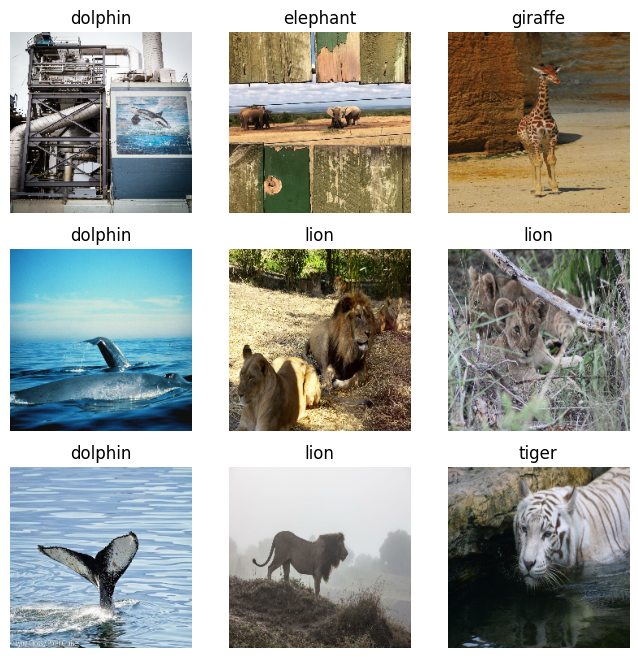

In [ ]:
#4.5: (Optional but Recommended) Show Sample Images
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [ ]:
#5.1: Create Data Augmentation Layer
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [ ]:
#5.2: Create Normalization Layer
normalization_layer = layers.Rescaling(1./255)


In [ ]:
#5.3: Apply Normalization to Dataset
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


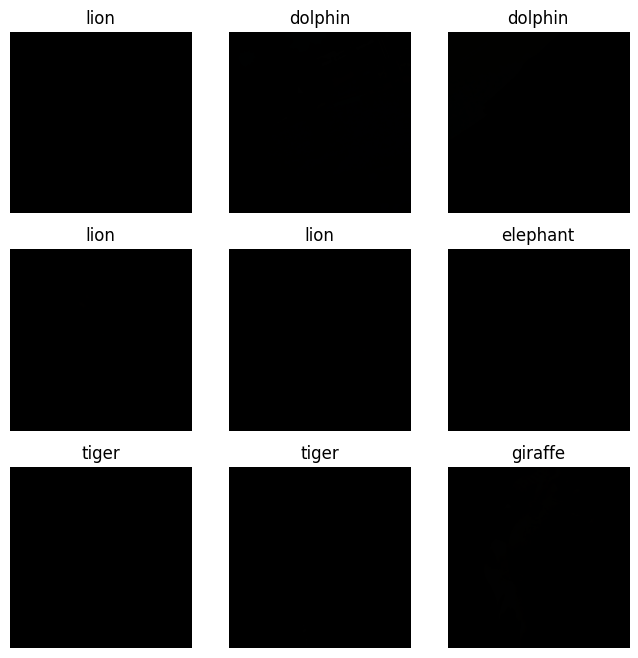

In [ ]:
#5.4: (Optional) Visualize Augmented Images
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        augmented = data_augmentation(images)
        plt.imshow(augmented[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")


Random flipping, rotation, zoom, and contrast regulation methods were used as data augmentation to enhance the diversity of the datasets used and decrease overfitting. Image normalization was also done by rescaling pixel values to the scale [0,1] and this enhanced training stability.

In [ ]:
#6.1: Import Model Tools
from tensorflow.keras import models


In [ ]:
# 6.2: Build the CNN Model
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])


In [ ]:
#6.3: View Model Summary (VERY IMPORTANT)
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (32, 222, 222, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (32, 111, 111, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (32, 109, 109, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (32, 54, 54, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (32, 52, 52, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (32, 26, 26, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (32, 86528)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (32, 256)              │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (32, 5)                │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,957 (84.86 MB)

 Trainable params: 22,245,957 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

The model belongs to three convolutional layers whose filters are of different sizes to obtain hierarchical spatial features. Spatial dimensions were reduced with the use of max pooling layers. It was then classified using fully connected dense layer and dropout to prevent overfitting. The last softmax layer gives the probability of the five animal classes.

In [ ]:
# 7.1: Compile the CNN Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


7.2: Why These Choices (IMPORTANT FOR REPORT)
✔ Optimizer: Adam

Fast convergence

Adaptive learning rate

Works well for image classification

✔ Loss: Sparse Categorical Crossentropy

Correct for multi-class classification

Works with integer labels (0–4)

✔ Metric: Accuracy

Easy to interpret

Required for model evaluation

In [ ]:
#8.1: Import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping



In [ ]:
# 8.2: Define Early Stopping Callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


STEP 8.3: Understand These Parameters (WRITE IN REPORT)

monitor='val_loss'
→ watches validation loss, not training loss

patience=5
→ waits 5 epochs before stopping

restore_best_weights=True
→ keeps the best model, not the last one

Report Sentence

Early stopping was used by observing validation loss using a patience of five epochs. This helped to avoid overfitting and only the best-performing model weights were kept.

In [ ]:
#9.1: Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)



Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 91s 987ms/step - accuracy: 0.3128 - loss: 1.8929 - val_accuracy: 0.5169 - val_loss: 1.1555
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 924ms/step - accuracy: 0.4627 - loss: 1.2153 - val_accuracy: 0.5379 - val_loss: 1.0952
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 925ms/step - accuracy: 0.5244 - loss: 1.1360 - val_accuracy: 0.5716 - val_loss: 1.0213
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 82s 915ms/step - accuracy: 0.5517 - loss: 1.0873 - val_accuracy: 0.5253 - val_loss: 1.2425
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 148s 980ms/step - accuracy: 0.5723 - loss: 1.0730 - val_accuracy: 0.5941 - val_loss: 0.9432
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 137s 924ms/step - accuracy: 0.6254 - loss: 0.9356 - val_accuracy: 0.6728 - val_loss: 0.8557
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 88s 973ms/step - accuracy: 0.6429 - loss: 0.9068 - val_accuracy: 0.6292 - val_loss: 1.0236
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 86s 950ms/step - accuracy: 0.5595 - loss: 1.0632 - val_ac

The concept of early stopping was used by tracking validation loss using a patience of five epochs. This served to prevent overfitting and the best model weights were automatic restored.

In [ ]:
# 9.2: Evaluate the Model
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 650ms/step - accuracy: 0.7449 - loss: 0.7891
Validation Accuracy: 0.7514045238494873
Validation Loss: 0.7382753491401672


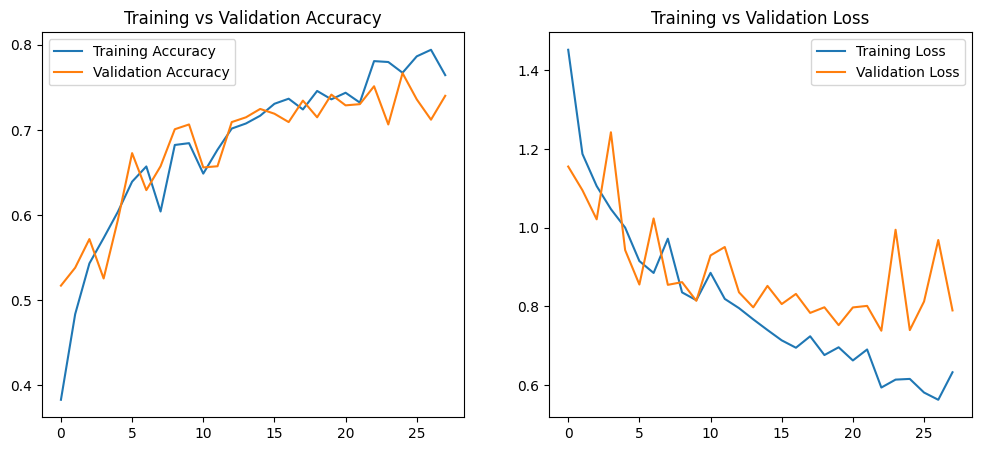

In [ ]:
# 9.3: Plot Accuracy and Loss
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


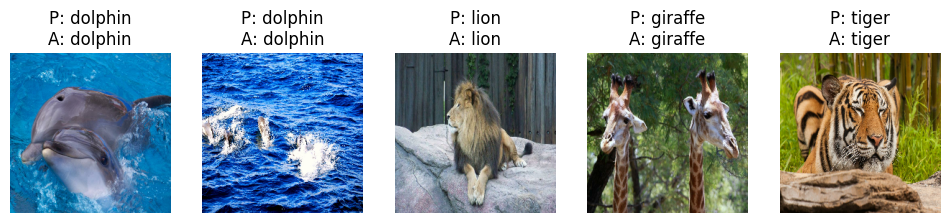

In [ ]:
# 9.4: Predict on Validation Images
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"P: {class_names[pred_labels[i]]}\n"
            f"A: {class_names[int(labels[i])]}"
        )
        plt.axis("off")

plt.show()


The CNN model did not begin to stabilize in accuracy of validation until after a number of epochs. Early termination avoided overfitting since training was terminated when the validation loss ceased to decrease. The validation curves and training curves show that there is good generalization. More drastic architectures or data augmentation might be provided to improve it further.

In [ ]:
# STEP 10: Evaluate model performance on validation data
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 663ms/step - accuracy: 0.7428 - loss: 0.7474
Validation Loss: 0.7382753491401672
Validation Accuracy: 0.7514045238494873


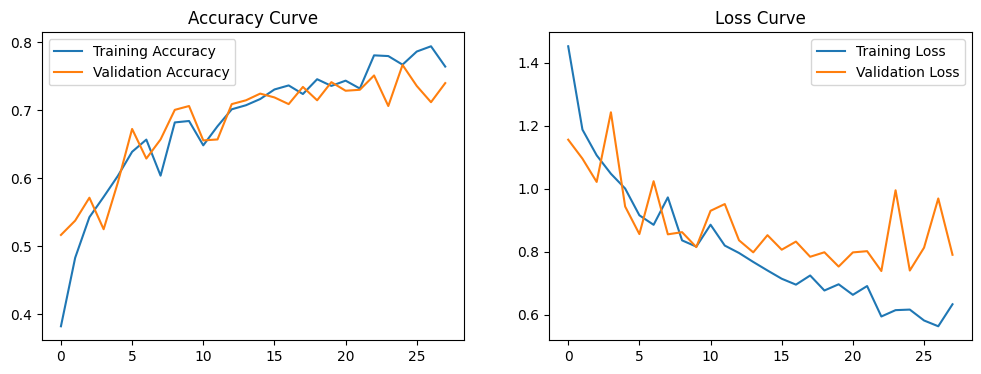

In [ ]:
# STEP 11: Plot training vs validation accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


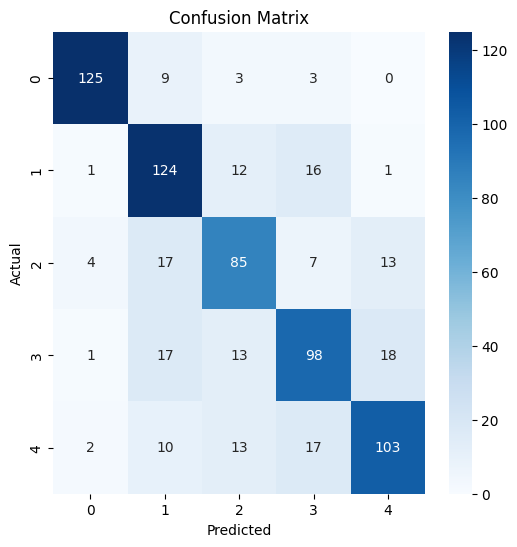

In [ ]:
# STEP 12: Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#13: Classification Report
print(classification_report(y_true, y_pred))



              precision    recall  f1-score   support

           0       0.94      0.89      0.92       140
           1       0.70      0.81      0.75       154
           2       0.67      0.67      0.67       126
           3       0.70      0.67      0.68       147
           4       0.76      0.71      0.74       145

    accuracy                           0.75       712
   macro avg       0.75      0.75      0.75       712
weighted avg       0.75      0.75      0.75       712



In [ ]:
# STEP 14: Save the trained model
model.save("animal_cnn_model.keras")


